In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
path = "household_power_consumption.txt"
df = pd.read_csv(path,sep=';')
df

C:\Users\admin\AppData\Local\Temp\ipykernel_2916\2089122745.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path,sep=';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [6]:
df.describe() 

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [8]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [10]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

In [11]:
df.dtypes

Date                             object
Time                             object
Global_active_power              object
Global_reactive_power            object
Voltage                          object
Global_intensity                 object
Sub_metering_1                   object
Sub_metering_2                   object
Sub_metering_3                  float64
DateTime                 datetime64[ns]
dtype: object

In [12]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    object        
 3   Global_reactive_power  object        
 4   Voltage                object        
 5   Global_intensity       object        
 6   Sub_metering_1         object        
 7   Sub_metering_2         object        
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 158.3+ MB


In [13]:
df['DateTime'].head()

0   2006-12-16 17:24:00
1   2006-12-16 17:25:00
2   2006-12-16 17:26:00
3   2006-12-16 17:27:00
4   2006-12-16 17:28:00
Name: DateTime, dtype: datetime64[ns]

In [14]:
df.set_index('DateTime', inplace=True) 
df.drop(['Date', 'Time'], axis=1, inplace=True) 
df.head() 

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [16]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

In [17]:
df.dropna(subset=['Global_active_power'], inplace=True) 

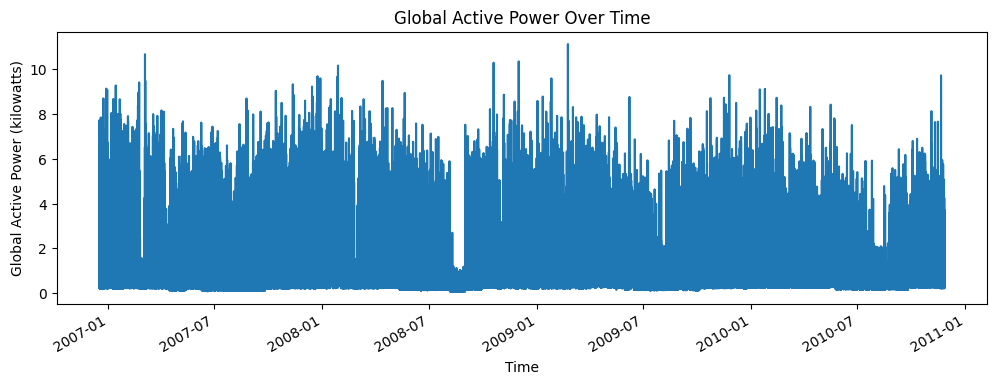

In [18]:
df['Global_active_power'].plot(figsize=(12, 4), title='Global Active Power Over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kilowatts)')
plt.show()

In [19]:
#Resample Global_active_power to daily, weekly, and monthly mean
daily = df['Global_active_power'].resample('D').mean()
daily

DateTime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
                ...   
2010-11-22    1.417733
2010-11-23    1.095511
2010-11-24    1.247394
2010-11-25    0.993864
2010-11-26    1.178230
Freq: D, Name: Global_active_power, Length: 1442, dtype: float64

In [20]:
weekly = df['Global_active_power'].resample('W').mean()
weekly

DateTime
2006-12-17    2.505248
2006-12-24    1.734186
2006-12-31    1.958376
2007-01-07    1.484233
2007-01-14    1.604954
                ...   
2010-10-31    0.958963
2010-11-07    1.154565
2010-11-14    1.335928
2010-11-21    1.107106
2010-11-28    1.186756
Freq: W-SUN, Name: Global_active_power, Length: 207, dtype: float64

In [22]:
monthly = df['Global_active_power'].resample('ME').mean()
monthly

DateTime
2006-12-31    1.901295
2007-01-31    1.546034
2007-02-28    1.401084
2007-03-31    1.318627
2007-04-30    0.891189
2007-05-31    0.985862
2007-06-30    0.826814
2007-07-31    0.667367
2007-08-31    0.764186
2007-09-30    0.969318
2007-10-31    1.103911
2007-11-30    1.294473
2007-12-31    1.626474
2008-01-31    1.459920
2008-02-29    1.181384
2008-03-31    1.245337
2008-04-30    1.115972
2008-05-31    1.024281
2008-06-30    0.994096
2008-07-31    0.794781
2008-08-31    0.276488
2008-09-30    0.987680
2008-10-31    1.136768
2008-11-30    1.387066
2008-12-31    1.275189
2009-01-31    1.410202
2009-02-28    1.247568
2009-03-31    1.226735
2009-04-30    1.140690
2009-05-31    1.012856
2009-06-30    0.840756
2009-07-31    0.618121
2009-08-31    0.664619
2009-09-30    0.986841
2009-10-31    1.144486
2009-11-30    1.274743
2009-12-31    1.364421
2010-01-31    1.430525
2010-02-28    1.375855
2010-03-31    1.130075
2010-04-30    1.027295
2010-05-31    1.095284
2010-06-30    0.969615
20

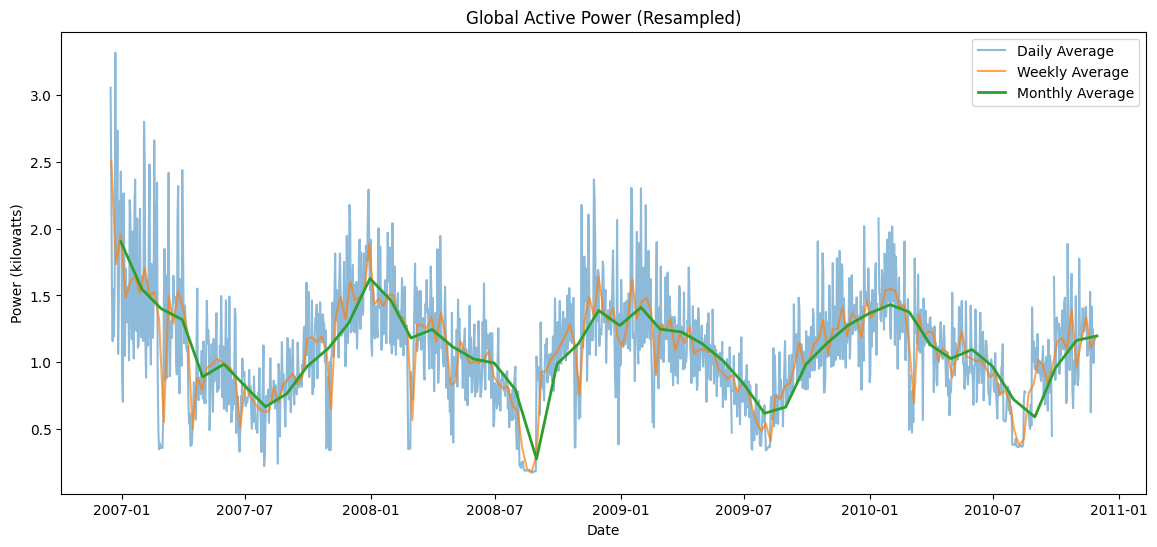

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(daily, label='Daily Average', alpha=0.5)
plt.plot(weekly, label='Weekly Average', alpha=0.7)
plt.plot(monthly, label='Monthly Average', linewidth=2)

plt.title('Global Active Power (Resampled)')
plt.xlabel('Date')
plt.ylabel('Power (kilowatts)')
plt.legend()
plt.show()

In [24]:
# Slice data for January 2007
df_jan2007 = df.loc['2007-01']
df_jan2007[['Global_active_power']].head()

,Global_active_power
DateTime,
2007-01-01 00:00:00,2.580
2007-01-01 00:01:00,2.552
2007-01-01 00:02:00,2.550
2007-01-01 00:03:00,2.550
2007-01-01 00:04:00,2.554


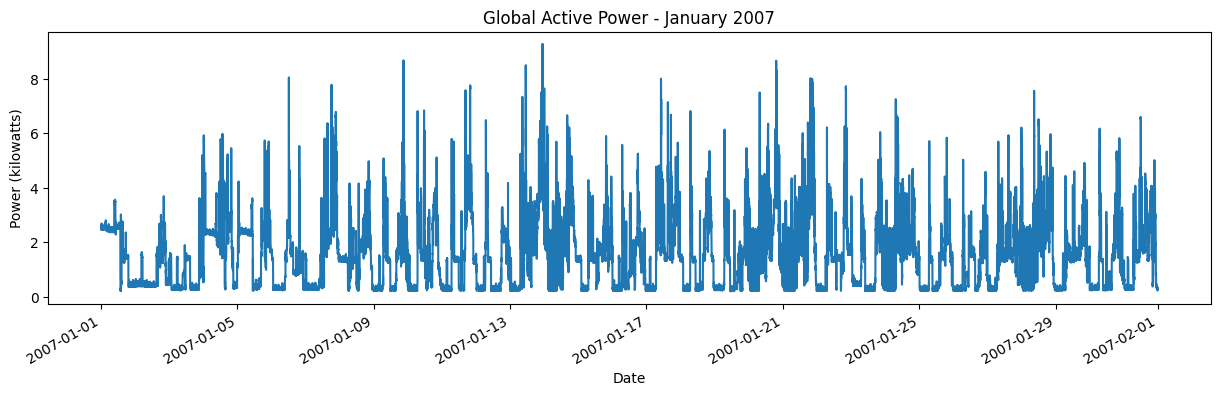

In [29]:
# Plot Global_active_power
df_jan2007['Global_active_power'].plot(figsize=(15, 4), title='Global Active Power - January 2007')
plt.xlabel('Date')
plt.ylabel('Power (kilowatts)')
plt.show()